# Phase 2 — Metric design: why accuracy is the wrong metric

**Learning goal:** on multi-label imbalanced data, accuracy is misleading. Learn micro vs
macro F1 and per-label PR curves.

This is the pivot of the whole project. Phase 1 produced two baselines whose probability
matrices are saved to disk; here we build the evaluation harness
([src/evaluate.py](../src/evaluate.py)) that every later phase reports through, and use it to
show three things:

1. Accuracy is disqualified — a model that predicts **nothing** beats a real model on it.
2. Micro-F1 and macro-F1 disagree, and the *direction* of the disagreement is a diagnostic.
3. Ranking models by micro-F1 selects the model that ignores rare labels.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import f1_score

from src.config import LABELS, RESULTS, SEED, set_seed, setup_logging
from src.data import get_split_data
from src.evaluate import compare_table, evaluate, plot_pr_curves

setup_logging()
set_seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

_, Y_test = get_split_data("test")
probs = {
    "balanced": np.load("../models/probs/baseline_test.npy"),
    "unweighted": np.load("../models/probs/baseline_unweighted_test.npy"),
}
print(f"test set: {Y_test.shape[0]:,} examples x {Y_test.shape[1]} labels")
print("positives per label:", dict(zip(LABELS, Y_test.sum(0).tolist())))

18:51:17 | INFO    | src.config | seed set to 42


18:51:18 | INFO    | src.data | loaded 159571 labeled comments from train.csv


18:51:18 | INFO    | src.data | label matrix (159571, 6) | positives per label: {'toxic': 15294, 'severe_toxic': 1595, 'obscene': 8449, 'threat': 478, 'insult': 7877, 'identity_hate': 1405}


test set: 23,936 examples x 6 labels
positives per label: {'toxic': 2294, 'severe_toxic': 239, 'obscene': 1268, 'threat': 72, 'insult': 1181, 'identity_hate': 211}


## 1. The disqualification of accuracy

Consider the laziest possible model: it outputs 0 for every label on every example. It has
no parameters and zero utility. Here is how it scores.

In [2]:
zeros = np.zeros_like(Y_test)

lazy = pd.DataFrame({
    "accuracy_if_always_0": [(Y_test[:, i] == 0).mean() for i in range(len(LABELS))],
    "f1_if_always_0": [f1_score(Y_test[:, i], zeros[:, i], zero_division=0) for i in range(len(LABELS))],
}, index=LABELS)
lazy["accuracy_if_always_0"] = (100 * lazy["accuracy_if_always_0"]).round(2)
display(lazy)

print(f"Exact-match (subset) accuracy : {100*(Y_test.sum(1) == 0).mean():.2f}%")
print(f"Mean per-label accuracy       : {100*(Y_test == zeros).mean():.2f}%")
print(f"Macro-F1                      : {f1_score(Y_test, zeros, average='macro', zero_division=0):.4f}")
print()
print("On `threat` this useless model is 99.70% accurate. Any metric that ranks it near the")
print("top of the leaderboard is measuring the wrong thing. Accuracy rewards predicting the")
print("majority class, and here the majority class is 'no label at all' (89.8% of rows).")

,accuracy_if_always_0,f1_if_always_0
toxic,90.42,0.0
severe_toxic,99.00,0.0
obscene,94.70,0.0
threat,99.70,0.0
insult,95.07,0.0
identity_hate,99.12,0.0


Exact-match (subset) accuracy : 89.79%
Mean per-label accuracy       : 96.33%
Macro-F1                      : 0.0000

On `threat` this useless model is 99.70% accurate. Any metric that ranks it near the
top of the leaderboard is measuring the wrong thing. Accuracy rewards predicting the
majority class, and here the majority class is 'no label at all' (89.8% of rows).


## 2. Micro vs macro F1 — what each one actually averages

- **Micro-F1** pools all `n_samples x n_labels` binary decisions into a single contingency
  table, then computes one F1. Every *decision* counts equally, so labels with many positives
  dominate. `toxic` supplies 2,294 of the 5,265 positive decisions in this test split.
- **Macro-F1** computes F1 separately per label, then averages the six numbers equally. Every
  *label* counts equally, so `threat` (72 positives) matters as much as `toxic` (2,294).

Recomputing both from scratch below, so the difference is mechanical rather than an appeal to
sklearn's authority.

In [3]:
def manual_micro_macro(y_true, y_pred):
    tp = (y_pred & y_true).sum(axis=0)
    fp = (y_pred & ~y_true.astype(bool)).sum(axis=0)
    fn = (~y_pred.astype(bool) & y_true).sum(axis=0)

    # macro: F1 per label, then a plain unweighted mean
    per_label_f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1)
    macro = per_label_f1.mean()

    # micro: sum the counts across labels FIRST, then one F1
    micro = 2 * tp.sum() / max(2 * tp.sum() + fp.sum() + fn.sum(), 1)
    return micro, macro, per_label_f1, tp, fp, fn


y_pred = (probs["balanced"] >= 0.5).astype(np.int8)
micro, macro, per_label_f1, tp, fp, fn = manual_micro_macro(Y_test, y_pred)

breakdown = pd.DataFrame({
    "TP": tp, "FP": fp, "FN": fn,
    "support": Y_test.sum(0),
    "share_of_positive_decisions_%": (100 * Y_test.sum(0) / Y_test.sum()).round(1),
    "F1": per_label_f1.round(4),
}, index=LABELS)
display(breakdown)

print(f"manual micro-F1 = {micro:.4f}   (pools {tp.sum():,} TP / {fp.sum():,} FP / {fn.sum():,} FN)")
print(f"manual macro-F1 = {macro:.4f}   (mean of {np.round(per_label_f1, 3).tolist()})")
print(f"sklearn micro   = {f1_score(Y_test, y_pred, average='micro', zero_division=0):.4f}")
print(f"sklearn macro   = {f1_score(Y_test, y_pred, average='macro', zero_division=0):.4f}")

,TP,FP,FN,support,share_of_positive_decisions_%,F1
toxic,1982,1211,312,2294,43.6,0.7224
severe_toxic,212,542,27,239,4.5,0.4270
obscene,1113,591,155,1268,24.1,0.7490
threat,59,158,13,72,1.4,0.4083
insult,995,921,186,1181,22.4,0.6426
identity_hate,147,547,64,211,4.0,0.3249


manual micro-F1 = 0.6560   (pools 4,508 TP / 3,970 FP / 757 FN)
manual macro-F1 = 0.5457   (mean of [0.722, 0.427, 0.749, 0.408, 0.643, 0.325])
sklearn micro   = 0.6560
sklearn macro   = 0.5457


## 3. The divergence, and why it is a diagnostic

Now evaluate both Phase 1 baselines through the harness. Watch what happens to the *ranking*
depending on which metric you trust.

In [4]:
results = {
    name: evaluate(Y_test, p, 0.5, name=f"baseline ({name}) @ 0.5")
    for name, p in probs.items()
}

summary = pd.DataFrame({
    name: {
        "macro-F1 (headline)": r["macro_f1"],
        "micro-F1": r["micro_f1"],
        "micro - macro gap": r["micro_macro_gap"],
        "macro-AP (threshold-free)": r["macro_average_precision"],
        "exact-match accuracy": r["accuracy_do_not_use_as_headline"]["subset_accuracy_exact_match"],
        "F1 threat": r["per_label"]["threat"]["f1"],
        "F1 identity_hate": r["per_label"]["identity_hate"]["f1"],
        "threat predictions": r["per_label"]["threat"]["n_predicted_positive"],
    }
    for name, r in results.items()
}).round(4)
display(summary)

better_micro = max(results, key=lambda k: results[k]["micro_f1"])
better_macro = max(results, key=lambda k: results[k]["macro_f1"])
print(f"Best by micro-F1 : {better_micro}")
print(f"Best by macro-F1 : {better_macro}")
if better_micro != better_macro:
    print()
    print("The two metrics pick DIFFERENT models. The unweighted model wins on micro-F1 while")
    print("predicting `threat` only 14 times against 72 true positives -- it buys its micro-F1")
    print("by being precise on frequent labels and silent on rare ones. Macro-F1 catches that;")
    print("micro-F1 rewards it. This is the whole argument for macro-F1 as the headline.")

,balanced,unweighted
macro-F1 (headline),0.5457,0.4789
micro-F1,0.6560,0.6675
micro - macro gap,0.1104,0.1886
macro-AP (threshold-free),0.6360,0.6296
exact-match accuracy,0.8702,0.9172
F1 threat,0.4083,0.2326
F1 identity_hate,0.3249,0.2481
threat predictions,217.0000,14.0000


Best by micro-F1 : unweighted
Best by macro-F1 : balanced

The two metrics pick DIFFERENT models. The unweighted model wins on micro-F1 while
predicting `threat` only 14 times against 72 true positives -- it buys its micro-F1
by being precise on frequent labels and silent on rare ones. Macro-F1 catches that;
micro-F1 rewards it. This is the whole argument for macro-F1 as the headline.


### Visualising the gap

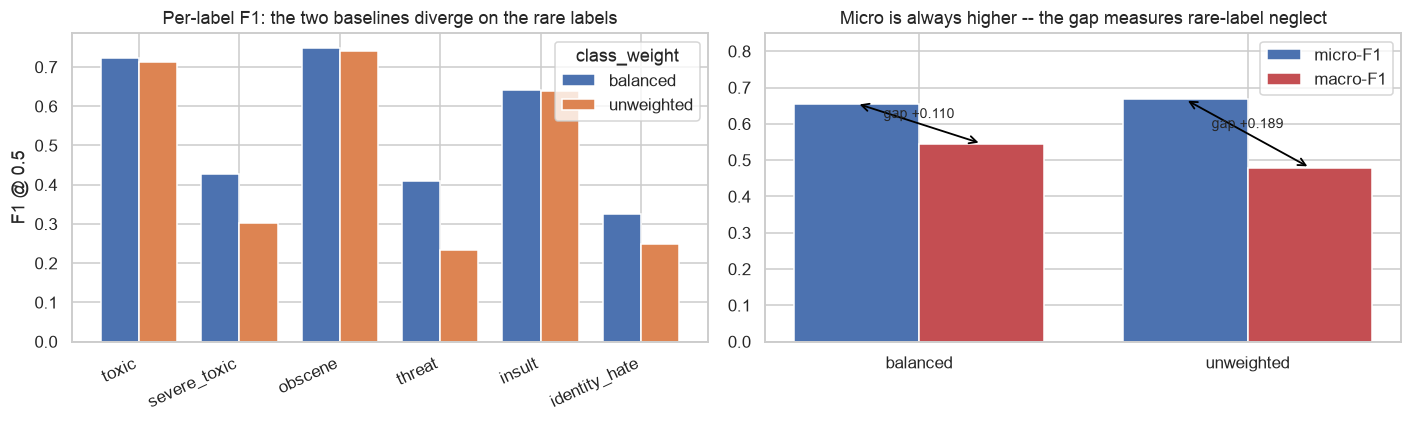

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(LABELS))
w = 0.38
for offset, (name, r) in zip((-w / 2, w / 2), results.items()):
    axes[0].bar(x + offset, [r["per_label"][l]["f1"] for l in LABELS], w, label=name)
axes[0].set_xticks(x, LABELS, rotation=25, ha="right")
axes[0].set_ylabel("F1 @ 0.5")
axes[0].set_title("Per-label F1: the two baselines diverge on the rare labels")
axes[0].legend(title="class_weight")

names = list(results)
axes[1].bar(np.arange(len(names)) - w / 2, [results[n]["micro_f1"] for n in names], w, label="micro-F1", color="#4C72B0")
axes[1].bar(np.arange(len(names)) + w / 2, [results[n]["macro_f1"] for n in names], w, label="macro-F1", color="#C44E52")
for i, n in enumerate(names):
    axes[1].annotate("", xy=(i - w / 2, results[n]["micro_f1"]), xytext=(i + w / 2, results[n]["macro_f1"]),
                     arrowprops=dict(arrowstyle="<->", color="black", lw=1.2))
    axes[1].text(i, (results[n]["micro_f1"] + results[n]["macro_f1"]) / 2 + 0.015,
                 f"gap {results[n]['micro_macro_gap']:+.3f}", ha="center", fontsize=9)
axes[1].set_xticks(np.arange(len(names)), names)
axes[1].set_ylim(0, 0.85)
axes[1].set_title("Micro is always higher -- the gap measures rare-label neglect")
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS / "metrics_micro_vs_macro.png", bbox_inches="tight")
plt.show()

## 4. Per-label PR curves

The threshold-free view. The dashed line in each panel is the label's positive rate — the
precision a coin-flip classifier would get — so it shows how much harder the rare labels are.

18:51:19 | INFO    | src.evaluate | wrote /Users/kavana/Documents/text-classifier/results/pr_baseline.png


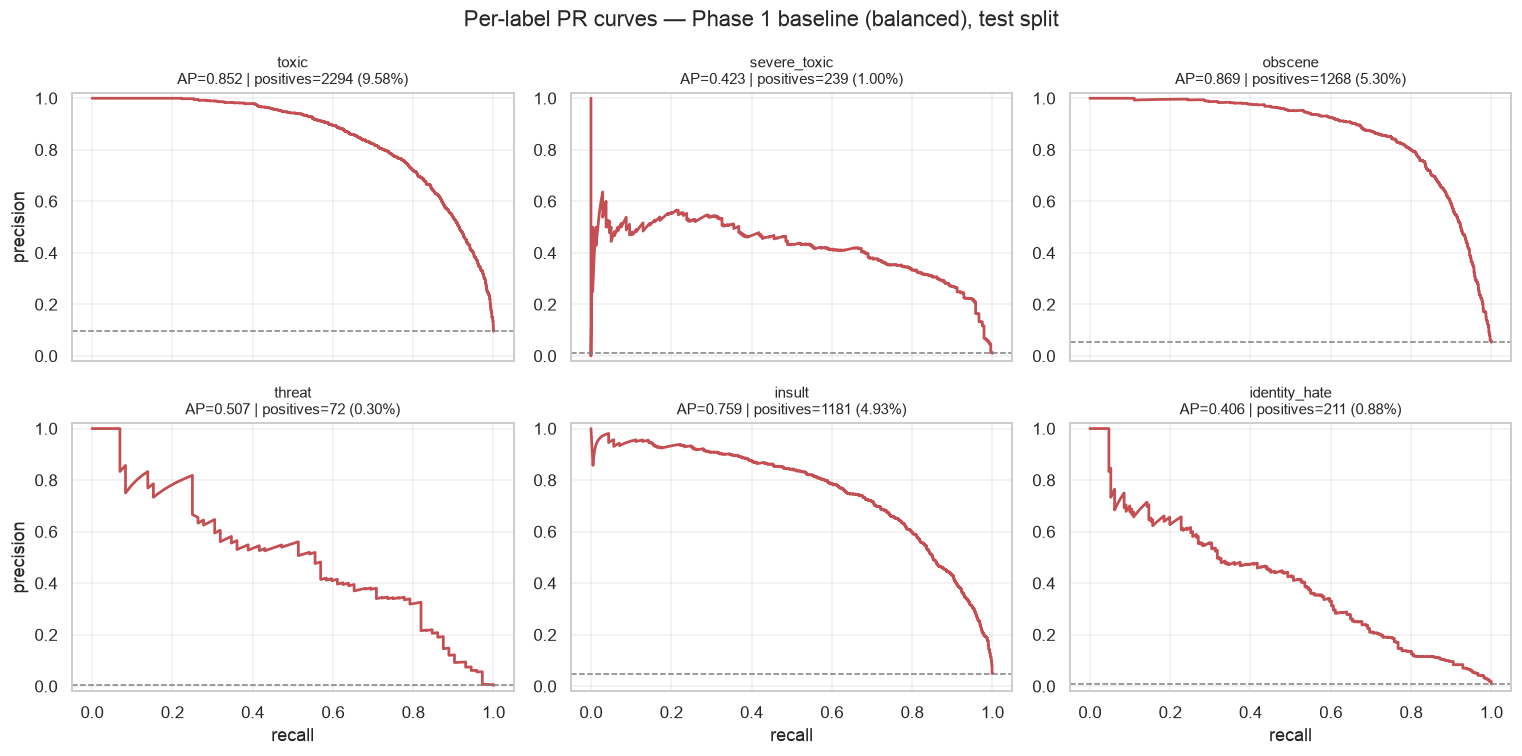

,average_precision,F1_at_0.5,positive_rate_%,AP_minus_F1
toxic,0.852,0.722,9.584,0.130
obscene,0.869,0.749,5.297,0.120
insult,0.759,0.643,4.934,0.116
threat,0.507,0.408,0.301,0.099
identity_hate,0.406,0.325,0.882,0.081
severe_toxic,0.423,0.427,0.998,-0.004


Where AP is much larger than F1@0.5, the model RANKS examples well but the threshold
is placed badly. That gap is recoverable without retraining -- which is Phase 4.


In [6]:
from IPython.display import Image, display as ipy_display

plot_pr_curves(Y_test, probs["balanced"], RESULTS / "pr_baseline.png",
               title="Per-label PR curves — Phase 1 baseline (balanced), test split")
ipy_display(Image(filename=str(RESULTS / "pr_baseline.png")))

ap = pd.DataFrame({
    "average_precision": [results["balanced"]["per_label"][l]["average_precision"] for l in LABELS],
    "F1_at_0.5": [results["balanced"]["per_label"][l]["f1"] for l in LABELS],
    "positive_rate_%": [100 * results["balanced"]["per_label"][l]["positive_rate"] for l in LABELS],
}, index=LABELS).round(3)
ap["AP_minus_F1"] = (ap["average_precision"] - ap["F1_at_0.5"]).round(3)
display(ap.sort_values("AP_minus_F1", ascending=False))

print("Where AP is much larger than F1@0.5, the model RANKS examples well but the threshold")
print("is placed badly. That gap is recoverable without retraining -- which is Phase 4.")

## 5. Preview: 0.5 is not the right threshold

Sweeping the threshold per label on this split shows the F1-maximizing point is nowhere near
0.5 for most labels. (Done here on **test** purely as an illustration of the shape; Phase 4
does it properly — tuning on validation only, then applying frozen thresholds to test.)

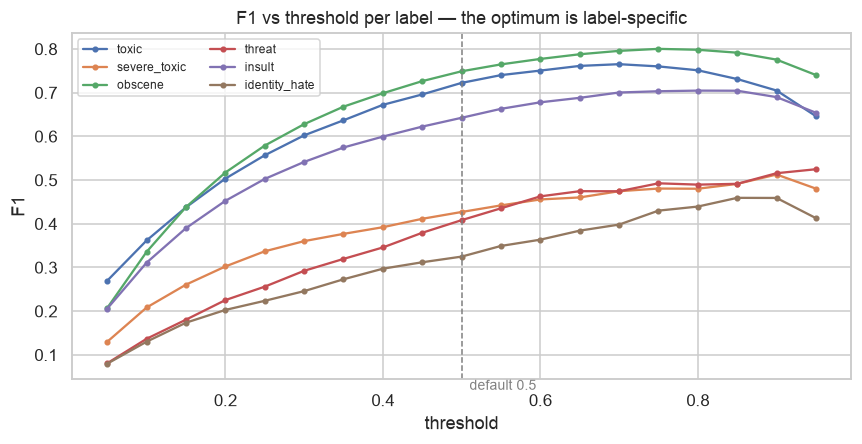

,best_threshold,F1_at_best,F1_at_0.5,gain
label,,,,
toxic,0.70,0.7652,0.7224,0.0428
severe_toxic,0.90,0.5127,0.4270,0.0857
obscene,0.75,0.8003,0.7490,0.0513
threat,0.95,0.5248,0.4083,0.1165
insult,0.80,0.7047,0.6426,0.0621
identity_hate,0.85,0.4593,0.3249,0.1344


Macro-F1 at 0.5 everywhere : 0.5457
Macro-F1 at per-label best : 0.6278  <- Phase 4 goes after this


In [7]:
grid = np.linspace(0.05, 0.95, 19)
fig, ax = plt.subplots(figsize=(8, 4.2))
rows = []
for i, label in enumerate(LABELS):
    f1s = [f1_score(Y_test[:, i], probs["balanced"][:, i] >= t, zero_division=0) for t in grid]
    ax.plot(grid, f1s, marker="o", ms=3, label=label)
    best = int(np.argmax(f1s))
    # Compute F1@0.5 directly rather than looking 0.5 up in the grid: linspace values
    # are floats and 0.5 is not guaranteed to be exactly representable in the sequence.
    f1_at_half = f1_score(Y_test[:, i], probs["balanced"][:, i] >= 0.5, zero_division=0)
    rows.append({"label": label, "best_threshold": grid[best], "F1_at_best": f1s[best],
                 "F1_at_0.5": f1_at_half})
ax.axvline(0.5, ls="--", color="grey", lw=1)
ax.text(0.51, 0.02, "default 0.5", fontsize=9, color="grey")
ax.set_xlabel("threshold")
ax.set_ylabel("F1")
ax.set_title("F1 vs threshold per label — the optimum is label-specific")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS / "metrics_threshold_preview.png", bbox_inches="tight")
plt.show()

prev = pd.DataFrame(rows).set_index("label").round(4)
prev["gain"] = (prev["F1_at_best"] - prev["F1_at_0.5"]).round(4)
display(prev)
print(f"Macro-F1 at 0.5 everywhere : {prev['F1_at_0.5'].mean():.4f}")
print(f"Macro-F1 at per-label best : {prev['F1_at_best'].mean():.4f}  <- Phase 4 goes after this")

In [8]:
# Persist the Phase 2 re-evaluation of both Phase 1 baselines.
for name, r in results.items():
    r["split"] = "test"
    (RESULTS / f"phase2_baseline_{'' if name == 'balanced' else 'unweighted_'}test.json").write_text(json.dumps(r, indent=2))

print(compare_table([(f"Phase 1 baseline ({n})", r) for n, r in results.items()]))

| model | macro-F1 | micro-F1 | macro-AP | F1 toxic | F1 severe_toxic | F1 obscene | F1 threat | F1 insult | F1 identity_hate |
|---|---|---|---|---|---|---|---|---|---|
| Phase 1 baseline (balanced) | **0.5457** | 0.6560 | 0.6360 | 0.722 | 0.427 | 0.749 | 0.408 | 0.643 | 0.325 |
| Phase 1 baseline (unweighted) | **0.4789** | 0.6675 | 0.6296 | 0.713 | 0.302 | 0.740 | 0.233 | 0.638 | 0.248 |



## Phase 2 findings

**Accuracy is disqualified.** An all-zeros model scores **89.79% exact-match accuracy** and
**96.33% mean per-label accuracy** on the test split, including **99.70% on `threat`**, with
macro-F1 of exactly **0.0**. No metric that ranks that model highly can be the headline. From
here on accuracy appears only inside the `all_zeros_baseline` block of each results JSON, as
a control.

**The micro/macro gap measures rare-label neglect.** Micro-F1 exceeds macro-F1 for both
baselines (+0.110 balanced, +0.189 unweighted). Micro-F1 pools decisions, so the 2,294 `toxic`
positives outvote the 72 `threat` positives ~32:1; macro-F1 weights the labels equally, so
neglecting one of six costs a sixth of the score. The size of the gap is therefore a direct
read on how unevenly a model is spending its capacity.

**Micro-F1 would have chosen the worse model.** The unweighted baseline scores *higher* on
micro-F1 (0.6675 vs 0.6560) while scoring far lower on macro-F1 (0.4789 vs 0.5457). It earns
that micro-F1 by being conservative and precise on frequent labels while predicting `threat`
just 14 times against 72 true positives. Had we selected on micro-F1 — or worse, on accuracy
— we would have shipped the model that is blind to the rarest and most safety-critical label.

**Much of the loss is a threshold artefact, not a modeling failure.** Average precision is
threshold-free, and for several labels it sits far above F1@0.5 — `threat` has AP 0.507
against F1 0.408, `identity_hate` AP 0.406 against F1 0.325. The ranking is better than the
0.5 operating point suggests, so a per-label threshold recovers real score **without
retraining**. The sweep in section 5 confirms the optimum is label-specific and mostly far
from 0.5. Phase 4 does this properly, tuning on validation and freezing before touching test.